In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')


In [5]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4151,ham,What's nannys address?,NaN,NaN,NaN
2672,ham,Super msg da:)nalla timing.,NaN,NaN,NaN
1959,ham,Howz that persons story,NaN,NaN,NaN
2211,ham,Just gettin a bit arty with my collages at the...,NaN,NaN,NaN
1206,spam,"As a SIM subscriber, you are selected to recei...",NaN,NaN,NaN


In [ ]:
df.shape #sms,col

(5572, 5)

In [ ]:
#stages:
#1: Data cleaning
#2: EDA (Exploratory Data Analysis)
#3: Text preprocessing
#4: Model building
#5: Evaluation
#6: Improvements depending on evaluation
#7: Convert into website
#8: Deploy

1:Data Cleaning

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [8]:
#drop last 3 columns because it has very few entries
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [9]:
df.sample(5)

,v1,v2
4943,ham,Wrong phone! This phone! I answer this one but...
1738,ham,K go and sleep well. Take rest:-).
3015,ham,"&lt;#&gt; is fast approaching. So, Wish u a v..."
3622,ham,"Damn, poor zac doesn't stand a chance"
2798,ham,I've told him that i've returned it. That shou...


In [10]:
#renaming the columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
2970,ham,Height of Confidence: All the Aeronautics prof...
954,spam,Filthy stories and GIRLS waiting for your
928,ham,Oh all have to come ah?
1769,ham,Ha... Both of us doing e same thing. But i got...
4754,ham,U wan 2 haf lunch i'm in da canteen now.


In [12]:
#we want numbers where ham and spam is written
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [13]:
df['target']=encoder.fit_transform(df['target']) #ham=0,spam=1


In [14]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#Two things we always do is;
#1->is there any missing values or not
#2->check duplicate values
df.isnull().sum()

target    0
text      0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(403)

In [20]:
#remove duplicates
df=df.drop_duplicates(keep='first')
df.duplicated().sum()
df.shape

(5169, 2)

2.EDA


In [21]:
#check how much percent is spam and ham are sms
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

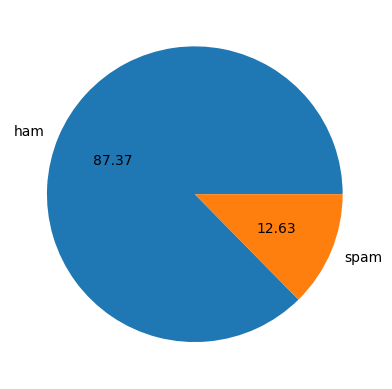

In [22]:
#if we represent in pie char
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()


In [ ]:
#the above pie chart show that data is imbalanced..because spam and ham percenatage are very different from each other

now we can find how many alphabets,words,sentences uses in the dataset

In [33]:
import nltk

In [39]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MMT\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MMT\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
#the columns we made are: 
#col1=no.of char in sms ,col2=no of words,col3=no.of sentences


In [41]:
df['num_chars']=df['text'].apply(len) #this give len of each sentence

In [42]:
df.head()

,target,text,num_chars
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:

df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x))) #count no.of words

In [46]:
df.head()

,target,text,num_chars,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [47]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x))) #no.of sentences

In [48]:
df.head()

,target,text,num_chars,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [50]:
#now i want to check what is happening by applying descibe
df[['num_chars','num_words','num_sentences']].describe()

,num_chars,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [51]:
#tokenizze above code for ham
df[df['target']==0][['num_chars','num_words','num_sentences']].describe()

,num_chars,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [52]:
#tokenizze above code for spam
df[df['target']==1][['num_chars','num_words','num_sentences']].describe()

,num_chars,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_chars', ylabel='Count'>

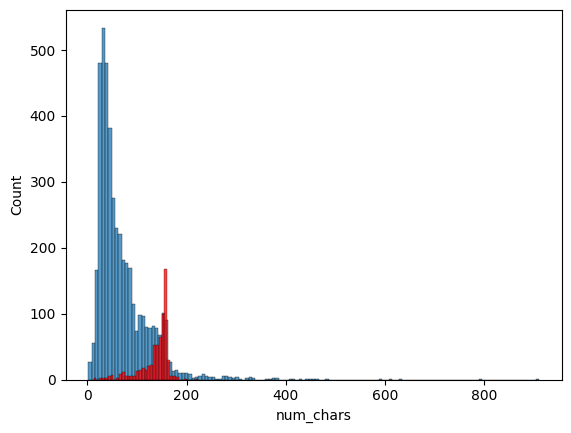

In [ ]:
#now plot histogram to see ham and spam
import seaborn as sns
sns.histplot(df[df['target']==0]['num_chars']) #ham sms
sns.histplot(df[df['target']==1]['num_chars'],color='red') #spam
#means ham msgs are made with more char ,while spam msgs are made with less chars


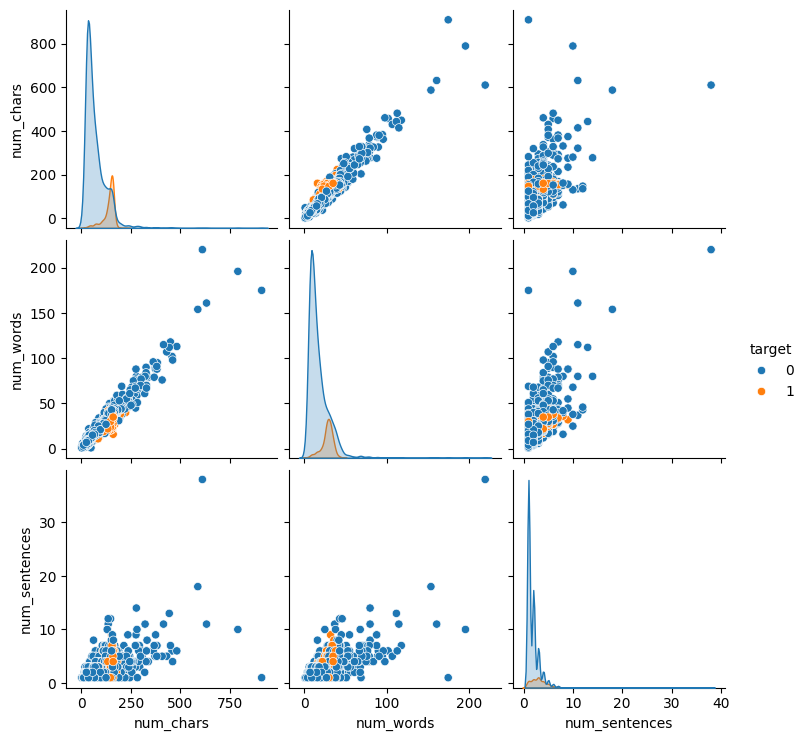

In [55]:
#see relationships between columns by pairplpot
sns.pairplot(df,hue='target')

<Axes: >

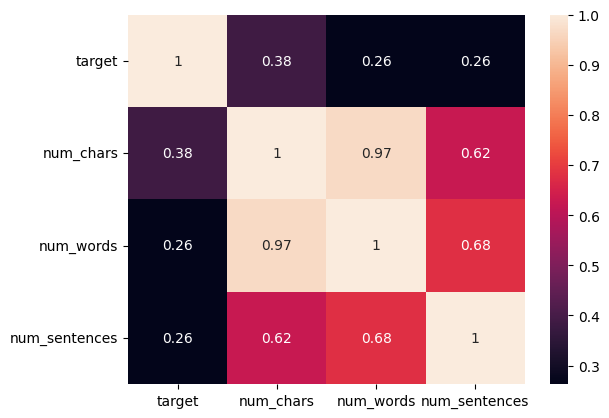

In [59]:
#find correlations
sns.heatmap(df.corr(numeric_only=True),annot=True)

3. DATA PREPROCESSING
*lower case
*Tokenization
*Rmoving special chars
*Removing stop words and punctuation  0>jinka sentence ma actual menaing ni hota..bs sentence ko banane k liye use karte hain
*Stemming ->aik hi type k words ko same consider karein gein..e.g dance,dancing,dances are same considers

In [91]:
from nltk.corpus import stopwords
nltk.download('stopwords')

import string
string.punctuation

from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MMT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [98]:
#create a func to perfrom above steps
def transform_text(text):
    text=text.lower()  #Lower
    text=nltk.word_tokenize(text) #tokenization
    y=[]
    for i in text:  #removing special chars
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [94]:
transform_text('Hi how are you rubab?')
transform_text('Did you like my presentation on ML?')
transform_text('I loved the YT lectures on ML.How about you?')

'love yt lectur'

In [100]:
df['transformed_text']=df['text'].apply(transform_text)
df.head()

,target,text,num_chars,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [105]:
#now we make word cloud from ham and spam ..means ham and spam ma se jo imp words hain unko bara karke show karein gein
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

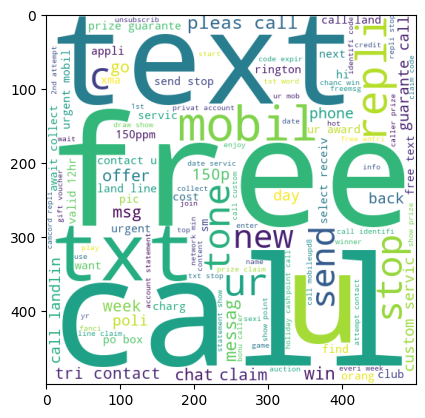

In [106]:
plt.imshow(spam_wc)

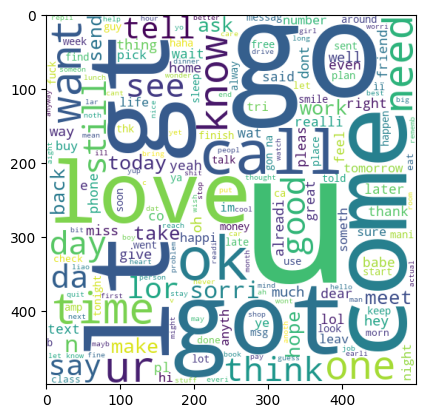

In [108]:
spam_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

In [109]:
#top 30 words of ham and spam
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

len(spam_corpus)

9939

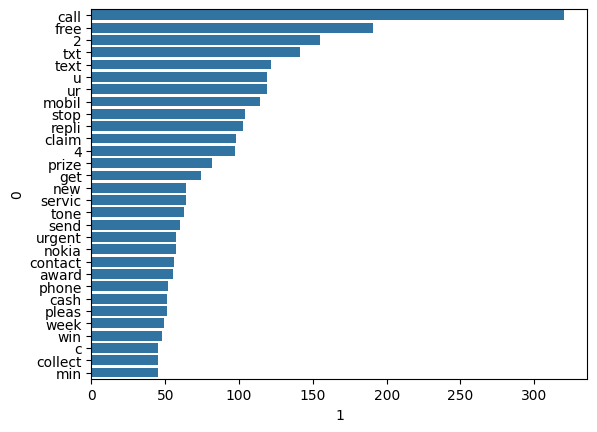

In [117]:
from collections import Counter
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=top_words[1], y=top_words[0])
plt.xticks(rotation='horizontal')
plt.show()

4: Build a model 'Naive bayes'

In [ ]:
#input=transformed_text  ,output=target
#convet the input into number or vectors by bagofwords or DFIDF or word_to_vect

In [154]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()

y = df['target'].values

In [155]:

X.shape

(5169, 3000)

In [156]:
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [158]:
# apply train test split
from sklearn.model_selection import train_test_split


In [159]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [160]:
#call algo
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [161]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1)) 
#as precition score is 0.5 ,so it is not a good result

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [162]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
#its output is better than gnb

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [163]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))
#this is much better than all

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [ ]:
#we can go with multinomial

#now we improve the model.
#fro this: 
#1: change the max_features parameter of TfIdf


In [ ]:
#if new sms come,we do 3 steps:
# 1:preprocessing 2:vectorize 3:apply algo

In [166]:
#for this we pickle 2 files
import pickle 
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))  #wb=write binary